# 18_归一化方法-数据归一化

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们今天先把归一化和大家聊聊\~

**数据归一化**是指将数据按比例缩放到一个特定的范围（如[0, 1]或[-1, 1]），以消除不同特征或变量之间量纲的影响，使其具有相同的尺度。

这是一种常见的预处理方法，特别是在机器学习和数据分析中。

1. **最小-最大归一化**（Min-Max Normalization）：将数据线性缩放到指定范围（如[0, 1]）


$$
X' = \frac{X - X_{min}}{X_{max} - X_{min}}
$$


1. **Z-score标准化**：将数据按其均值中心化，并按标准差缩


$$
X' = \frac{X - \mu}{\sigma}
$$


接下来，咱们从4个方面，聊聊数据归一化的重要性！\~

#### 数据归一化的重要性

1. **消除量纲差异**：不同特征的单位和取值范围可能差异很大（例如，收入以万元为单位，年龄以年为单位）。未经归一化的数据可能导致某些特征主导模型，而其他特征的影响被忽
2. **加速模型训练**：数据在统一的尺度下，优化算法（如梯度下降）的收敛速度会更快，减少迭代次
3. **提高模型性能**：许多算法（如支持向量机、K均值聚类、神经网络等）对特征尺度非常敏感，归一化有助于模型更准确地捕捉特征间的关
4. **提高结果的可解释性**：数据范围一致性可以帮助分析人员更直观地理解结

这个逻辑其实比较简单：假如一名运动教练，评估队员的综合实力。一个队员跑得快（100米速度），一个跳得高（跳高高度），另一个耐力强（跑马拉松）。因为它们的单位和范围差别太大，直接比较不公平。跑步速度是几秒，跳高是几米，马拉松时间是几个小时。你需要先把它们的表现都转化为「同一个标准」，比如把大家的分数都换算成1到100分，这样才能公平比较。

归一化就是干这个活儿：把不同单位和范围的数据「拉到同一条起跑线」，避免某个特征因为值特别大（或者特别小）而过分影响结果。这么做不仅公平，还让你更容易发现真正的优秀表现！

## 理论基础

数据归一化的本质是通过数学变换将数据映射到统一的尺度，使得不同特征具有相似的量级和分布。下面是归一化的数学原理和详细算法流程。

### 1. 最小-最大归一化（Min-Max Normalization）

最小-最大归一化通过线性变换将数据压缩到一个固定的范围（如[0, 1]或[-1, 1]）。

对于某个特征 $X$，每个样本 $x$的归一化公式为：


$$
x' = \frac{x - X_{min}}{X_{max} - X_{min}}
$$


其中：

- $x$是特征 $X$中的一个具体值；
- $X_{min}$是特征 $X$的最小值；
- $X_{max}$是特征 $X$的最大值；
- $x'$是归一化后的值。

归一化后的值 $x'$落在指定范围（通常是 [0, 1]）内。

#### 算法流程

1. 输入数据矩阵 $X$，每列表示一个特征，每行表示一个样本。
2. 针对每一列特征 $X_j$：$x'_j = \frac{x_j - X_{j,\text{min}}}{X_{j,\text{max}} - X_{j,\text{min}}}$

   1. 计算该特征的最小值 $X_{j,\text{min}}$和最大值 $X_{j,\text{max}}$。
   2. 按公式，对所有样本的特征值进行归一化：
3. 输出归一化后的数据矩阵 $X'$。

#### 特点

- 保留了数据的分布特点。
- 适用于数据分布有界的情况，但对异常值敏感。

### 2. Z-score标准化（Standardization）

Z-score标准化通过均值和标准差，将数据转换为标准正态分布（均值为0，标准差为1）。  
公式为：


$$
x' = \frac{x - \mu}{\sigma}
$$


其中：

- $\mu$是特征 $X$的均值；
- $\sigma$是特征 $X$的标准差；
- $x'$是标准化后的值。

标准化后的数据将具有均值为 0，标准差为 1 的特性。

#### 算法流程

1. 输入数据矩阵 $X$。
2. 针对每一列特征 $X_j$：

   1. 计算该特征的均值 $\mu_j$：  
   $\mu_j = \frac{1}{N} \sum_{i=1}^N x_{i,j}$
   2. 计算该特征的标准差 $\sigma_j$：  
   $\sigma_j = \sqrt{\frac{1}{N} \sum_{i=1}^N (x_{i,j} - \mu_j)^2}$
   3. 按公式，对所有样本的特征值进行标准化：  
   $x'_j = \frac{x_j - \mu_j}{\sigma_j}$
3. 输出标准化后的数据矩阵 $X'$。

#### 特点

- 不受异常值的极端范围影响。
- 常用于数据分布未界定或呈现正态分布的情况。

### 3. 最大绝对值归一化（Max-Abs Normalization）

最大绝对值归一化是通过特征的最大绝对值对每个数据点进行缩放，使得数据在 $[-1, 1]$ 的范围内。


$$
x' = \frac{x}{|X_{\text{max}}|}
$$


其中：$X_{\text{max}}$是特征 $X$的最大绝对值。

#### 算法流程

1. 输入数据矩阵 $X$。
2. 针对每一列特征 $X_j$：

   1. 计算最大绝对值 $X_{j,\text{max}}$。
   2. 按公式，对所有样本的特征值进行归一化：  
   $x'_j = \frac{x_j}{X_{j,\text{max}}}$
3. 输出归一化后的数据矩阵 $X'$。

#### 特点

- 对稀疏数据有效（如文本分类的词频矩阵）。
- 比最小-最大归一化更稳定，但不能改变分布。

### 4. 归一化算法的通用流程

1. **收集数据**：获取原始数据矩阵 $X$，通常是 $N \times M$的二维矩阵，其中 $N$是样本数，$M$是特征数。
2. **选择归一化方法**：根据数据特点和应用场景，选择适合的归一化方法（如 Min-Max 或 Z-score）。
3. **计算归一化参数**：针对每个特：

   - Min-Max 方法：计算最小值 $X_{min}$和最大值 $X_{max}$。
   - Z-score 方法：计算均值 $\mu$和标准差 $\sigma$。
   - Max-Abs 方法：计算最大绝对值 $X_{\text{max}}$。
4. **应用归一化公式**：按特定公式将原始数据逐列转换为归一化数据。
5. **输出归一化结果**：得到归一化后的数据矩阵 $X'$。

### 总结对比

| 方法 | 数学公式 | 适用场景 | 优点 | 缺点 |
|-|-|-|-|-|
| **最小-最大归一化** | $x' = \frac{x - X_{min}}{X_{max} - X_{min}}$ | 数据有界，范围需固定的场景 | 简单直观，适用范围明确 | 对异常值敏感 |
| **Z-score标准化** | $x' = \frac{x - \mu}{\sigma}$ | 数据接近正态分布或无明确范围的场景 | 考虑分布特性，不受量纲影响 | 可能受分布极端值干扰 |
| **最大绝对值归一化** | $x' = \frac{x}{\|X_{\text{max}}\|}$ | 稀疏数据（如文本分类） | 简单高效，适合稀疏矩阵 | 不能调整分布特性 |

通过这些归一化方法，可以根据具体需求对数据进行预处理，以便在后续分析或建模中取得更好的效果。

## 完整案例

咱们用Python和大家看看，数据归一化如何应用于数据集，同时结合图形化展示分析效果。

示例包括数据生成、归一化、对比以及可视化\~

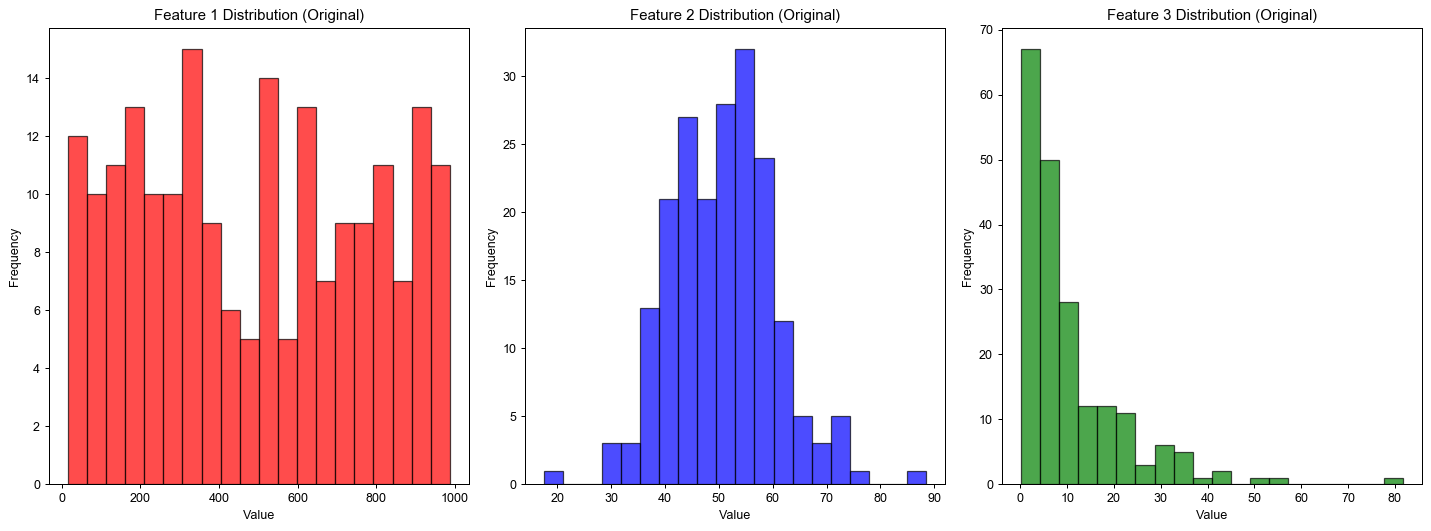

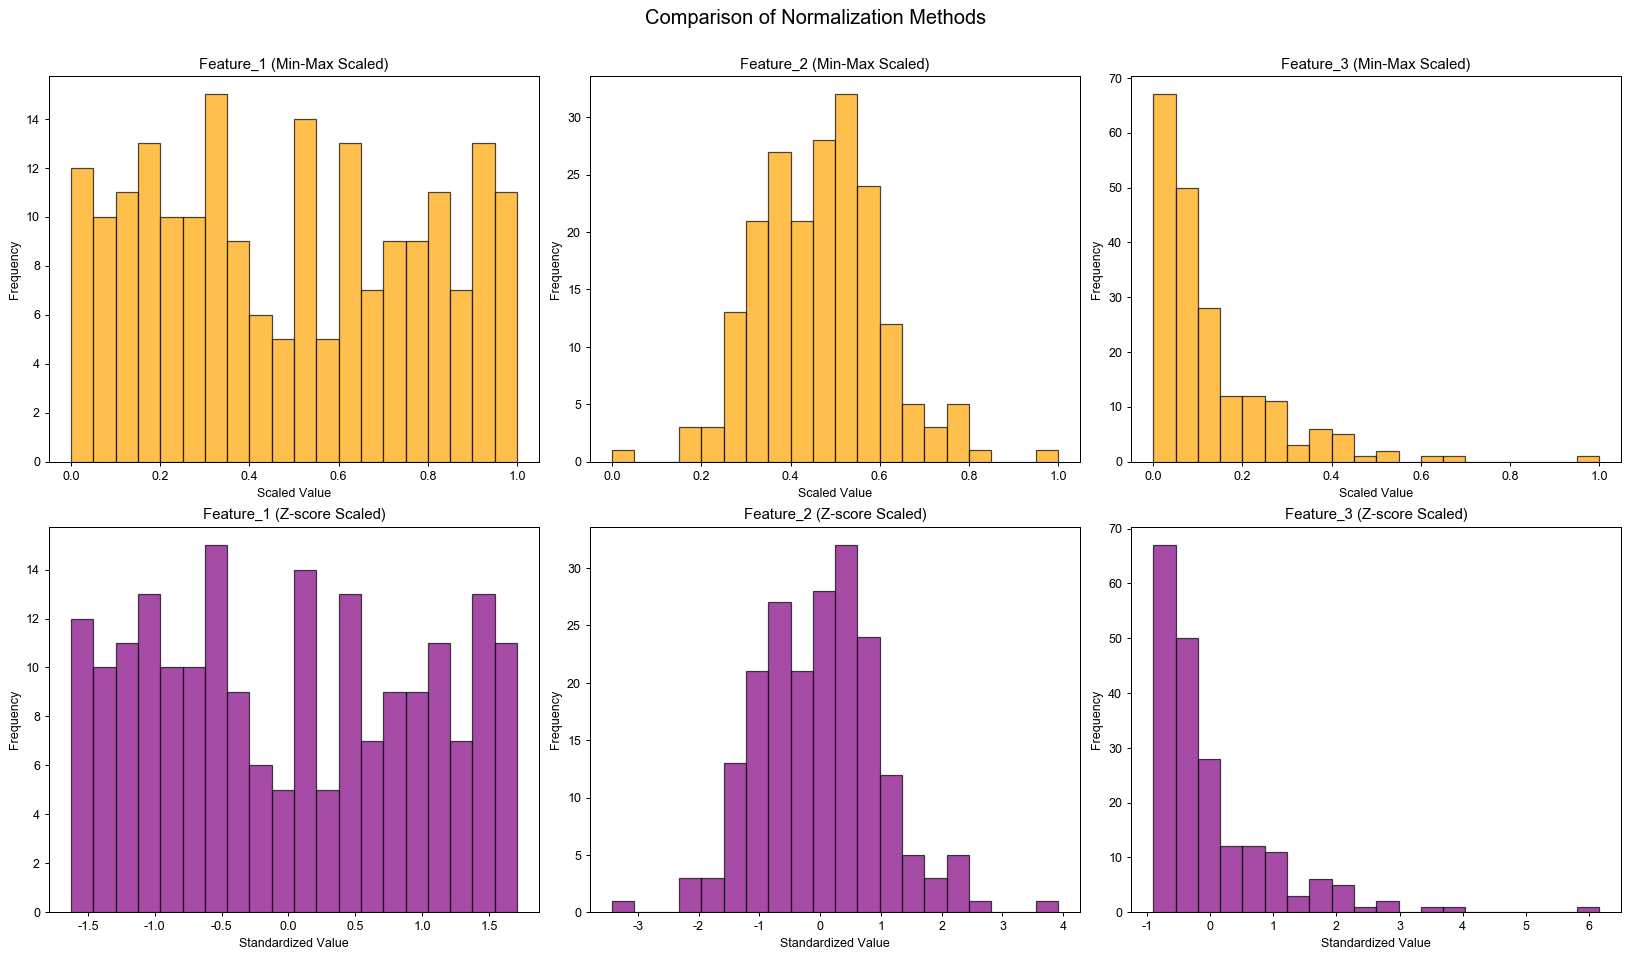

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

np.random.seed(42)

# 生成虚拟数据集
n_samples = 200
data = {
    "Feature_1": np.random.uniform(10, 1000, n_samples),   # 范围 [10, 1000]
    "Feature_2": np.random.normal(50, 10, n_samples),     # 正态分布，均值50，标准差10
    "Feature_3": np.random.exponential(1, n_samples) * 10, # 指数分布
    "Target": np.random.choice([0, 1], n_samples)          # 二分类目标
}

# 创建数据框
df = pd.DataFrame(data)

# 原始数据可视化
plt.figure(figsize=(16, 6))

plt.subplot(1, 3, 1)
plt.hist(df["Feature_1"], bins=20, color='red', alpha=0.7, edgecolor='black')
plt.title("Feature 1 Distribution (Original)")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
plt.hist(df["Feature_2"], bins=20, color='blue', alpha=0.7, edgecolor='black')
plt.title("Feature 2 Distribution (Original)")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.subplot(1, 3, 3)
plt.hist(df["Feature_3"], bins=20, color='green', alpha=0.7, edgecolor='black')
plt.title("Feature 3 Distribution (Original)")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# 数据归一化处理
# Min-Max归一化
scaler_minmax = MinMaxScaler()
df_minmax = pd.DataFrame(scaler_minmax.fit_transform(df.iloc[:, :-1]), columns=df.columns[:-1])

# Z-score标准化
scaler_zscore = StandardScaler()
df_zscore = pd.DataFrame(scaler_zscore.fit_transform(df.iloc[:, :-1]), columns=df.columns[:-1])

# 归一化后的数据可视化
fig, axs = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

# Min-Max归一化图
for i, feature in enumerate(df_minmax.columns):
    axs[0, i].hist(df_minmax[feature], bins=20, color='orange', alpha=0.7, edgecolor='black')
    axs[0, i].set_title(f"{feature} (Min-Max Scaled)")
    axs[0, i].set_xlabel("Scaled Value")
    axs[0, i].set_ylabel("Frequency")

# Z-score标准化图
for i, feature in enumerate(df_zscore.columns):
    axs[1, i].hist(df_zscore[feature], bins=20, color='purple', alpha=0.7, edgecolor='black')
    axs[1, i].set_title(f"{feature} (Z-score Scaled)")
    axs[1, i].set_xlabel("Standardized Value")
    axs[1, i].set_ylabel("Frequency")

# 设置布局
plt.suptitle("Comparison of Normalization Methods", fontsize=16, y=1.05)
plt.show()

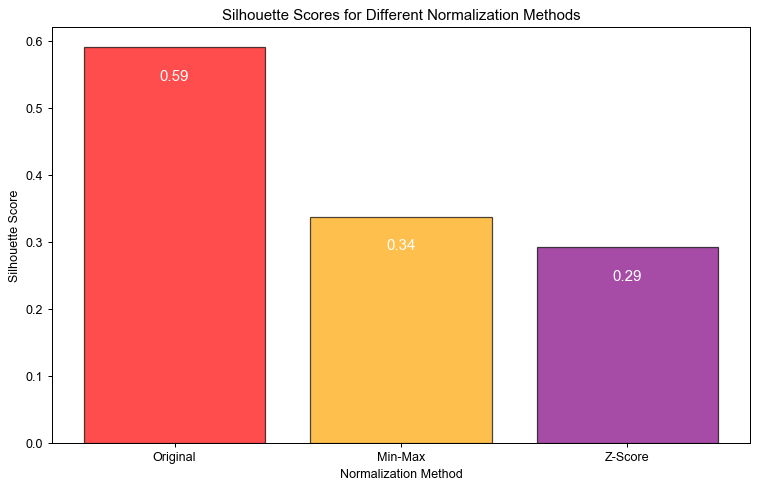

In [3]:
# 算法优化：归一化对K均值聚类的影响
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 聚类前的数据
X_original = df.iloc[:, :-1]
X_minmax = df_minmax
X_zscore = df_zscore

# 聚类结果
results = {}
for method, data in zip(['Original', 'Min-Max', 'Z-Score'], [X_original, X_minmax, X_zscore]):
    kmeans = KMeans(n_clusters=3, random_state=42)
    labels = kmeans.fit_predict(data)
    score = silhouette_score(data, labels)
    results[method] = score

# 可视化聚类结果
methods = list(results.keys())
scores = list(results.values())

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, scores, color=['red', 'orange', 'purple'], alpha=0.7, edgecolor='black')
plt.title("Silhouette Scores for Different Normalization Methods")
plt.ylabel("Silhouette Score")
plt.xlabel("Normalization Method")

# 添加数值标签
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 0.05, f"{score:.2f}", ha='center', color='white', fontsize=12)

plt.show()

1. 数据生成：模拟三个特征，分别来自均匀分布、正态分布和指数分布。
2. 归一化：使用 **Min-Max** 和 **Z-score** 两种方法对数据进行归一化。
3. 可视化对比：直方图对比归一化前后的数据分布。
4. 算法优化：通过 K-means 聚类分析不同归一化方法对聚类性能的影响（以轮廓系数为评价指标）。

### 可视化分析

**原始分布**：展示特征在归一化前的原始分布。

![原文参考图，当前结果见代码输出](attachments/img_011.png)

**归一化效果对比**：以直方图展示 Min-Max 和 Z-score 的归一化效果。

![原文参考图，当前结果见代码输出](attachments/img_012.png)

**性能对比**：通过聚类轮廓系数，展示归一化对算法性能的提升。

![原文参考图，当前结果见代码输出](attachments/img_013.png)

## 应用场景

### 数据归一化适用的问题类型

1. **特征量纲差异较大的问题**：特征之间的量纲和数值范围相差过大（如收入以万元为单位、年龄以年为单位），需要统一尺度。
2. **算法对尺度敏感的问题**：归一化特别适用于以下类型的算法：

   - 距离度量相关（如欧氏距离、余弦相似度）：K均值聚类、K近邻（KNN）。
   - 梯度计算敏感的优化算法：神经网络、线性回归。
   - 基于特征权重的模型：支持向量机（SVM）。
3. **需要加速模型收敛的场景**：特别是深度学习中的梯度下降法，归一化有助于快速收敛。

### 数据归一化的优缺点

**优点**：

1. **提高模型性能**：通过消除量纲差异，让模型能更准确地捕捉特征之间的关系。
2. **加速模型训练**：优化算法（如梯度下降）更快收敛，减少训练时间。
3. **改善结果的稳定性**：特别是在多特征的高维空间中，归一化能防止数值不均衡对结果造成干扰。

**缺点**：

1. **对异常值敏感**：最小-最大归一化容易受极端值影响，导致范围不均。
2. **增加计算复杂度**：归一化需要预处理步骤，增加计算开销。
3. **可能丢失特征分布信息**：在某些场景中，归一化可能弱化重要特征的权重。

### 数据归一化的前提条件

1. **特征之间存在明显的量纲差异**：如果所有特征的数值范围和单位相似，归一化可能不必要。
2. **模型对尺度敏感**：对于基于树的模型（如决策树、随机森林、XGBoost），归一化通常不是必须的，因为它们对特征尺度不敏感。
3. **需要对训练和测试数据一致处理**：归一化必须基于训练数据计算的参数（如均值和标准差）来转换测试数据，保证一致性。